In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42

In [32]:
df = pd.read_csv(r"C:\Users\User\Desktop\cleaned_online_shoppers_intention_for_ml.csv")
print(f'Dataset shape: {df.shape}')
print(f'Target distribution:\n{df["Revenue"].value_counts()}')
print(f'Class imbalance ratio: {df["Revenue"].value_counts()[0] / df["Revenue"].value_counts()[1]:.1f}:1')

df.head()


Dataset shape: (12205, 20)
Target distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64
Class imbalance ratio: 5.4:1


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Num,Visitor_New_Visitor,Visitor_Other,Visitor_Returning_Visitor
0,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.318962,-0.31024,1,1,1,1,0,0,2,0,0,1
1,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.595451,-0.450137,1.268054,-0.318962,-0.31024,2,2,1,2,0,0,2,0,0,1
2,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.318962,-0.31024,4,1,9,3,0,0,2,0,0,1
3,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.627404,0.654748,2.134590,-0.318962,-0.31024,3,2,2,4,0,0,2,0,0,1
4,-0.702302,-0.460019,-0.398824,-0.246257,-0.494387,-0.301889,-0.008183,0.184884,-0.318962,-0.31024,3,3,1,4,1,0,2,0,0,1


## Project Overview

- We have data about 12,205 website visitors (pages visited, time spent, weekend flag, etc.)
- The goal is to predict whether a visitor will make a purchase (Revenue = 1) or not (Revenue = 0).
- Three models are built and compared: **Logistic Regression** (interpretable baseline), **Random Forest** (ensemble), and **XGBoost** (gradient boosting).
- Class imbalance (~84% non-purchase vs ~16% purchase) is handled via **SMOTE** applied strictly inside each cross-validation fold and on the training set only, preventing data leakage.

### Corrections applied (from verification audit):
1. **Visitor reference category dropped** — `Visitor_Returning_Visitor` removed to prevent perfect multicollinearity in the dummy variable set.
2. **Month_Num one-hot encoded** — treated as categorical rather than a continuous ordinal integer.
3. **Double-scaling fixed** — the source CSV already contains StandardScaled continuous features; the scaler is now applied only to the 9 engineered features.


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Administrative             12205 non-null  float64
 1   Administrative_Duration    12205 non-null  float64
 2   Informational              12205 non-null  float64
 3   Informational_Duration     12205 non-null  float64
 4   ProductRelated             12205 non-null  float64
 5   ProductRelated_Duration    12205 non-null  float64
 6   BounceRates                12205 non-null  float64
 7   ExitRates                  12205 non-null  float64
 8   PageValues                 12205 non-null  float64
 9   SpecialDay                 12205 non-null  float64
 10  OperatingSystems           12205 non-null  int64  
 11  Browser                    12205 non-null  int64  
 12  Region                     12205 non-null  int64  
 13  TrafficType                12205 non-null  int

In [34]:
df["Revenue"].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

In [35]:
df.isna().sum()

Administrative               0
Administrative_Duration      0
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                    0
PageValues                   0
SpecialDay                   0
OperatingSystems             0
Browser                      0
Region                       0
TrafficType                  0
Weekend                      0
Revenue                      0
Month_Num                    0
Visitor_New_Visitor          0
Visitor_Other                0
Visitor_Returning_Visitor    0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
# X = all visitor features; y = purchase outcome (1=bought, 0=did not buy)
X = df.drop(columns=["Revenue"])
y = df["Revenue"]

print(f"Dataset shape : {df.shape}")
print(f"Class distribution:\n{y.value_counts()}\n")


Dataset shape : (12205, 20)
Class distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64



In [38]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Num,Visitor_New_Visitor,Visitor_Other,Visitor_Returning_Visitor
0,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.318962,-0.31024,1,1,1,1,0,0,2,0,0,1
1,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.595451,-0.450137,1.268054,-0.318962,-0.31024,2,2,1,2,0,0,2,0,0,1
2,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.318962,-0.31024,4,1,9,3,0,0,2,0,0,1
3,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.627404,0.654748,2.134590,-0.318962,-0.31024,3,2,2,4,0,0,2,0,0,1
4,-0.702302,-0.460019,-0.398824,-0.246257,-0.494387,-0.301889,-0.008183,0.184884,-0.318962,-0.31024,3,3,1,4,1,0,2,0,0,1


## Feature Engineering

We create new interaction and ratio features that capture richer behavioural signals.
Note: the 10 original continuous columns are already **StandardScaler-transformed** in the source file.
The 9 engineered features below are derived from those scaled values and will be re-scaled
after the train/test split (on training data only) to normalise their distributions.

All new features are derived from existing columns only — **no data leakage**.


In [39]:
df_fe = df.copy()
df_fe['Admin_TimePerPage'] = df_fe['Administrative_Duration'] / df_fe['Administrative'].replace(0, np.nan)
df_fe['Info_TimePerPage'] = df_fe['Informational_Duration']  / df_fe['Informational'].replace(0, np.nan)
df_fe['Product_TimePerPage'] = df_fe['ProductRelated_Duration'] / df_fe['ProductRelated'].replace(0, np.nan)
df_fe['Engagement_Score'] = df_fe['ProductRelated_Duration'] + df_fe['PageValues']
df_fe['BounceExit_Interaction']= df_fe['BounceRates'] * df_fe['ExitRates']
df_fe['PageValue_Per_Product'] = df_fe['PageValues'] / df_fe['ProductRelated'].replace(0, np.nan)
df_fe['Total_Pages'] = df_fe['Administrative'] + df_fe['Informational'] + df_fe['ProductRelated']
df_fe['Total_Duration'] = df_fe['Administrative_Duration'] + df_fe['Informational_Duration'] + df_fe['ProductRelated_Duration']
df_fe['Weekend_Special'] = df_fe['Weekend'] * df_fe['SpecialDay']

new_features = [
    'Admin_TimePerPage', 'Info_TimePerPage', 'Product_TimePerPage',
    'Engagement_Score', 'BounceExit_Interaction', 'PageValue_Per_Product',
    'Total_Pages', 'Total_Duration', 'Weekend_Special'
]
df_fe[new_features] = df_fe[new_features].fillna(0)
print(f"Shape after feature engineering: {df_fe.shape}")
df_fe.head()


Shape after feature engineering: (12205, 29)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Visitor_Returning_Visitor,Admin_TimePerPage,Info_TimePerPage,Product_TimePerPage,Engagement_Score,BounceExit_Interaction,PageValue_Per_Product,Total_Pages,Total_Duration,Weekend_Special
0,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.318962,-0.31024,...,1,0.655016,0.617458,0.903155,-0.947755,13.632490,0.458136,-1.797345,-1.335070,-0.00000
1,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.595451,-0.450137,1.268054,-0.318962,-0.31024,...,1,0.655016,0.617458,0.883731,-0.914414,-0.570798,0.473384,-1.774919,-1.301728,-0.00000
2,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.318962,-0.31024,...,1,0.655016,0.617458,0.903155,-0.947755,13.632490,0.458136,-1.797345,-1.335070,-0.00000
3,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.627404,0.654748,2.134590,-0.318962,-0.31024,...,1,0.655016,0.617458,0.931153,-0.946366,1.397618,0.473384,-1.774919,-1.333680,-0.00000
4,-0.702302,-0.460019,-0.398824,-0.246257,-0.494387,-0.301889,-0.008183,0.184884,-0.318962,-0.31024,...,1,0.655016,0.617458,0.610632,-0.620851,-0.001513,0.645167,-1.595514,-1.008165,-0.31024


In [40]:
# Encoding audit
print('=== Encoding Audit ===')
print('\nOne-hot encoded VisitorType columns (from cleaned file):')
visitor_cols = [c for c in df_fe.columns if c.startswith('Visitor_')]
print(visitor_cols)
print(f'Sum check (should equal 1 per row): {df_fe[visitor_cols].sum(axis=1).value_counts().to_dict()}')

# Visitor reference category: drop Visitor_Returning_Visitor to prevent
# perfect multicollinearity (the 3 dummy columns always sum to 1, making them
# linearly dependent). Returning_Visitor is the most common category and serves
# as the reference. Its effect is captured in the intercept.
if 'Visitor_Returning_Visitor' in df_fe.columns:
    df_fe = df_fe.drop(columns=['Visitor_Returning_Visitor'])
    print("\n[FIX 1] Dropped 'Visitor_Returning_Visitor' as reference category to avoid dummy variable trap.")
visitor_cols_after = [c for c in df_fe.columns if c.startswith('Visitor_')]
print(f'Visitor columns remaining: {visitor_cols_after}')

print('\nMonth_Num value counts (1=Jan..12=Dec):')
print(df_fe['Month_Num'].value_counts().sort_index().to_dict())

# Month_Num: one-hot encode instead of treating as a continuous integer.
# Treating month as a linear ordinal implies December (12) is arithmetically 6x
# February (2), which has no semantic meaning. OHE lets LR fit a free coefficient
# per month. drop_first=True removes January (absent anyway; Feb becomes reference).
df_fe = pd.get_dummies(df_fe, columns=['Month_Num'], prefix='Month', drop_first=True)
print('\n[FIX 2] One-hot encoded Month_Num (reference = lowest present month).')
month_cols = [c for c in df_fe.columns if c.startswith('Month_')]
print(f'Month dummy columns created: {month_cols}')

nominal_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']
print(f'\nNominal integer columns to one-hot encode: {nominal_cols}')
for col in nominal_cols:
    print(f'  {col}: {sorted(df_fe[col].unique())} ({df_fe[col].nunique()} unique values)')

df_encoded = pd.get_dummies(df_fe, columns=nominal_cols, prefix=nominal_cols, drop_first=True)

print(f'\nShape before OHE nominal: {df_fe.shape}')
print(f'Shape after  OHE nominal: {df_encoded.shape}')


=== Encoding Audit ===

One-hot encoded VisitorType columns (from cleaned file):
['Visitor_New_Visitor', 'Visitor_Other', 'Visitor_Returning_Visitor']
Sum check (should equal 1 per row): {1: 12205}

[FIX 1] Dropped 'Visitor_Returning_Visitor' as reference category to avoid dummy variable trap.
Visitor columns remaining: ['Visitor_New_Visitor', 'Visitor_Other']

Month_Num value counts (1=Jan..12=Dec):
{2: 181, 3: 1860, 5: 3329, 6: 285, 7: 432, 8: 433, 9: 448, 10: 549, 11: 2982, 12: 1706}

[FIX 2] One-hot encoded Month_Num (reference = lowest present month).
Month dummy columns created: ['Month_3', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']

Nominal integer columns to one-hot encode: ['OperatingSystems', 'Browser', 'Region', 'TrafficType']
  OperatingSystems: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] (8 unique values)
  Browser: [np.int64(1), np.int64(2), np.int64(3), np.int64(4

In [41]:
# Final feature matrix and target vector
X_full = df_encoded.drop(columns=['Revenue'])
y      = df_encoded['Revenue']
print(f"Features: {X_full.shape[1]} | Samples: {X_full.shape[0]}")

Features: 77 | Samples: 12205


## Feature Correlation & Multicollinearity Removal

High inter-feature correlation (multicollinearity) destabilises Logistic Regression coefficients.  
We identify and drop one feature from each highly correlated pair (|r| > 0.85).

Top 15 features correlated with Revenue:
PageValues                 0.492
Engagement_Score           0.443
ExitRates                  0.204
Total_Pages                0.167
ProductRelated             0.156
Month_11                   0.154
ProductRelated_Duration    0.150
BounceRates                0.145
Total_Duration             0.141
Administrative             0.136
TrafficType_2              0.114
Visitor_New_Visitor        0.103
BounceExit_Interaction     0.099
Informational              0.094
Administrative_Duration    0.092


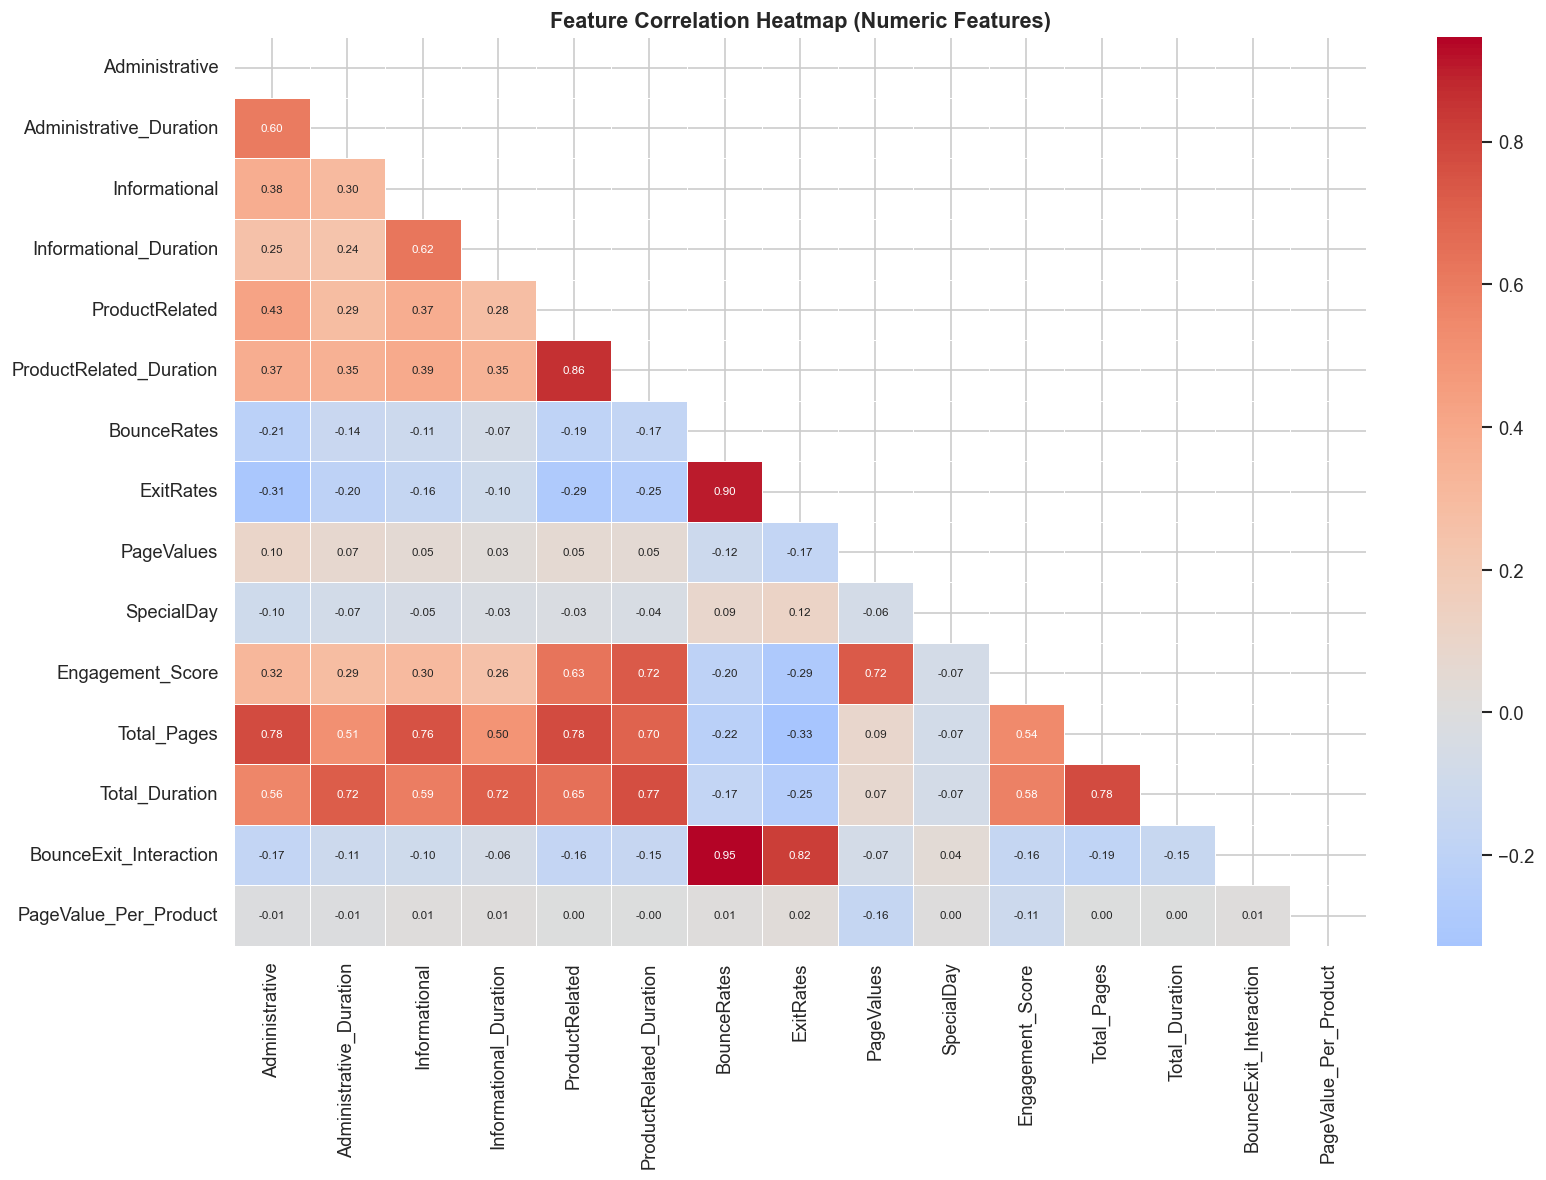


Features dropped due to high multicollinearity (|r|>0.85): ['ProductRelated_Duration', 'ExitRates', 'BounceExit_Interaction', 'Browser_11']
Features remaining: 73


In [42]:
#Correlation of all features with target
corr_with_target = X_full.corrwith(y).abs().sort_values(ascending=False)
print('Top 15 features correlated with Revenue:')
print(corr_with_target.head(15).round(3).to_string())

# Heatmap of base numeric features
base_num = ['Administrative','Administrative_Duration','Informational','Informational_Duration',
            'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates',
            'PageValues','SpecialDay','Engagement_Score','Total_Pages','Total_Duration',
            'BounceExit_Interaction','PageValue_Per_Product']
corr_matrix = X_full[base_num].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (Numeric Features)', fontweight='bold')
plt.tight_layout(); plt.show()

# Drop highly correlated features (|r| > 0.85) — prevent multicollinearity
corr_abs = X_full.corr().abs()
upper    = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
to_drop  = [col for col in upper.columns if (upper[col] > 0.85).any()]
print(f'\nFeatures dropped due to high multicollinearity (|r|>0.85): {to_drop}')

X_filtered = X_full.drop(columns=to_drop)
print(f'Features remaining: {X_filtered.shape[1]}')


## Train / Test Split

We perform an 80/20 **stratified split** first, then fit **StandardScaler** **only on the training set**
and **only on the 9 engineered features** — not on the original continuous features which are already
StandardScaled in the source file.

This corrects the double-scaling issue identified during verification.


In [43]:
# Double-Scaling Correction
# The cleaned CSV already has the original 10 continuous features StandardScaled
# (confirmed: mean≈0, std≈1 for Administrative, BounceRates, PageValues, etc.).
# Re-scaling them would distort values unnecessarily.
#
# Only the 9 engineered features (created in Cell 10) need scaling — they were
# derived from already-scaled values via division/multiplication so their
# distributions are non-standard.
#
# Nominal/ordinal columns (Month_*, Visitor_*, OperatingSystems dummies, etc.)
# are binary/integer and do not need scaling.

# Engineered features that need scaling (non-trivial distributions)
engineered_features = [
    'Admin_TimePerPage', 'Info_TimePerPage', 'Product_TimePerPage',
    'Engagement_Score', 'BounceExit_Interaction', 'PageValue_Per_Product',
    'Total_Pages', 'Total_Duration', 'Weekend_Special'
]
# Only scale engineered features that survived multicollinearity removal
to_scale = [c for c in engineered_features if c in X_filtered.columns]

# Binary/dummy columns (no scaling needed)
binary_cols_check = [c for c in X_filtered.columns if X_filtered[c].dropna().isin([0, 1]).all()]

print(f'[FIX 3] Engineered features to scale: {len(to_scale)}')
print(f'Pre-scaled original features (left unchanged): '
      f'{len([c for c in X_filtered.columns if c not in to_scale and c not in binary_cols_check])}')
print(f'Binary/dummy columns (no scaling): {len(binary_cols_check)}')

# Train/test split (BEFORE fitting scaler — no leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]:,} samples | Test set: {X_test.shape[0]:,} samples')
print(f'Train class distribution: {y_train.value_counts().to_dict()}')
print(f'Test  class distribution: {y_test.value_counts().to_dict()}')

# Fit scaler ONLY on engineered features, using train set statistics only
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

if to_scale:
    X_train_scaled[to_scale] = scaler.fit_transform(X_train[to_scale])  # fit on train only
    X_test_scaled[to_scale]  = scaler.transform(X_test[to_scale])       # transform with train stats

print(f'\nFinal train feature matrix shape: {X_train_scaled.shape}')
print(f'Final test  feature matrix shape: {X_test_scaled.shape}')
print(f'Columns scaled (engineered only): {to_scale}')


[FIX 3] Engineered features to scale: 8
Pre-scaled original features (left unchanged): 8
Binary/dummy columns (no scaling): 57

Train set: 9,764 samples | Test set: 2,441 samples
Train class distribution: {0: 8238, 1: 1526}
Test  class distribution: {0: 2059, 1: 382}

Final train feature matrix shape: (9764, 73)
Final test  feature matrix shape: (2441, 73)
Columns scaled (engineered only): ['Admin_TimePerPage', 'Info_TimePerPage', 'Product_TimePerPage', 'Engagement_Score', 'PageValue_Per_Product', 'Total_Pages', 'Total_Duration', 'Weekend_Special']


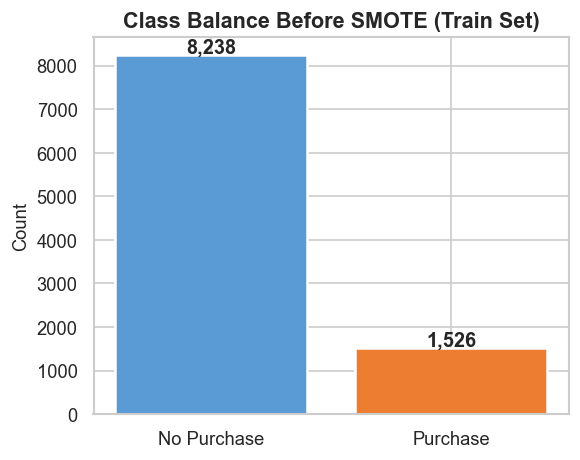

In [44]:
# Visualise class balance before SMOTE
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Purchase', 'Purchase'], y_train.value_counts().sort_index().values,
       color=['#5b9bd5', '#ed7d31'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(y_train.value_counts().sort_index().values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Class Balance Before SMOTE (Train Set)', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


## Class Imbalance Handling: SMOTE (Training Set Only)

**SMOTE** (Synthetic Minority Over-sampling Technique) synthesises new minority-class samples.  
It is applied **only on the training set** after the split, the test set is never touched.


In [45]:
#Apply SMOTE only on training data (no leakage into test set)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE — Train: {X_train_scaled.shape[0]:,}')
print(f'After  SMOTE — Train: {X_train_sm.shape[0]:,} | Class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}')
print(f'Test set (unchanged): {X_test_scaled.shape[0]:,}')


Before SMOTE — Train: 9,764
After  SMOTE — Train: 16,476 | Class distribution: {1: 8238, 0: 8238}
Test set (unchanged): 2,441


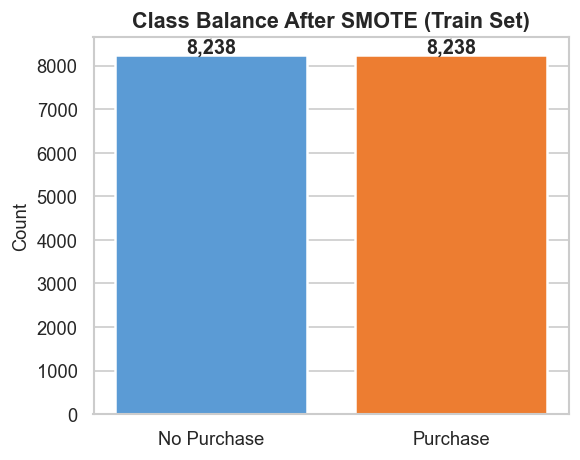

In [46]:
# Visualise class balance after SMOTE
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Purchase', 'Purchase'], pd.Series(y_train_sm).value_counts().sort_index().values,
       color=['#5b9bd5', '#ed7d31'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(pd.Series(y_train_sm).value_counts().sort_index().values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Class Balance After SMOTE (Train Set)', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

## Model 1: Logistic Regression

Logistic Regression is the interpretable **baseline** model for binary classification.  
We use **5-fold stratified cross-validation** to estimate generalisation performance.

In [47]:
#SMOTE inside CV pipeline, prevents synthetic samples leaking across folds
# Using ImbPipeline ensures SMOTE is re-fit independently on each CV fold's
# training portion, giving an unbiased estimate of generalisation performance.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# CV is now run on the ORIGINAL (unbalanced) training data; SMOTE is applied
# inside the pipeline on each fold independently — no leakage between folds.
cv_roc = cross_val_score(lr_pipeline, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(lr_pipeline, X_train_scaled, y_train, cv=cv, scoring='f1',      n_jobs=-1)

print('=== Logistic Regression — 5-Fold Cross-Validation (SMOTE in pipeline) ===')
print(f'ROC-AUC : {cv_roc.mean():.4f}  ± {cv_roc.std():.4f}')
print(f'F1-Score: {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')

# GridSearchCV with the same ImbPipeline — param keys use clf__ prefix
param_grid_lr = {
    'clf__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__solver' : ['lbfgs', 'liblinear'],
    'clf__penalty': ['l2']
}

grid_lr = GridSearchCV(
    ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    param_grid_lr,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_scaled, y_train)   # fit on unbalanced train; SMOTE happens inside

print(f'\nBest parameters: {grid_lr.best_params_}')
print(f'Best CV ROC-AUC: {grid_lr.best_score_:.4f}')

lr_best = grid_lr.best_estimator_

y_pred_lr = lr_best.predict(X_test_scaled)
y_prob_lr = lr_best.predict_proba(X_test_scaled)[:, 1]

print('\n=== Logistic Regression — Test Set Performance ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'Avg Prec : {average_precision_score(y_test, y_prob_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Purchase', 'Purchase']))


=== Logistic Regression — 5-Fold Cross-Validation (SMOTE in pipeline) ===
ROC-AUC : 0.8647  ± 0.0124
F1-Score: 0.5889  ± 0.0074
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV ROC-AUC: 0.8928

=== Logistic Regression — Test Set Performance ===
Accuracy : 0.8599
F1-Score : 0.6250
ROC-AUC  : 0.8988
Avg Prec : 0.6491

              precision    recall  f1-score   support

 No Purchase       0.95      0.88      0.91      2059
    Purchase       0.54      0.75      0.62       382

    accuracy                           0.86      2441
   macro avg       0.74      0.81      0.77      2441
weighted avg       0.88      0.86      0.87      2441



## Logistic Regression: Visualizations

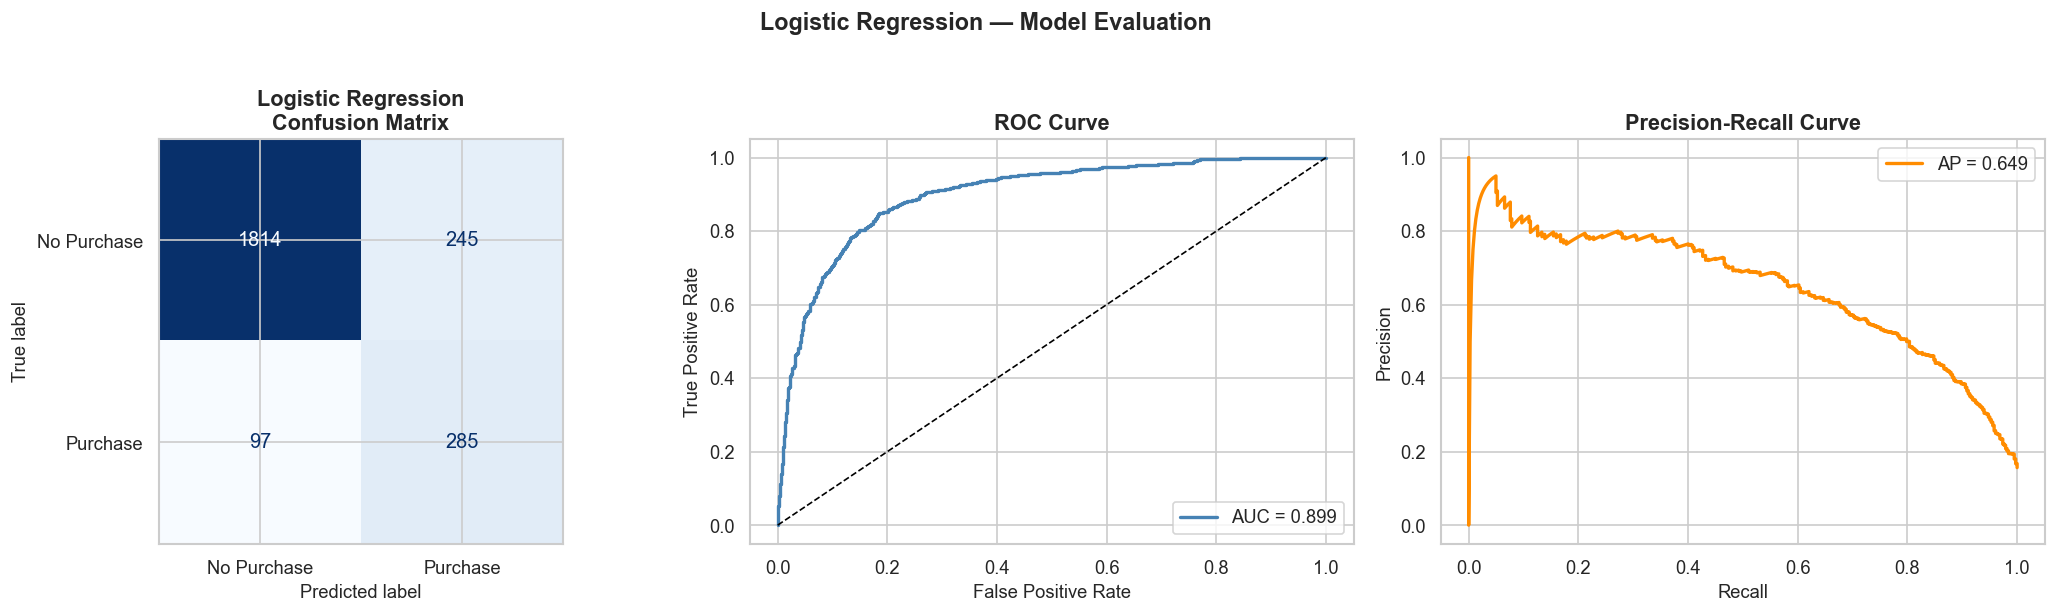

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['No Purchase', 'Purchase']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_prob_lr):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)
axes[2].plot(recall, precision, color='darkorange', lw=2,
             label=f'AP = {average_precision_score(y_test, y_prob_lr):.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='upper right')

plt.suptitle('Logistic Regression — Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

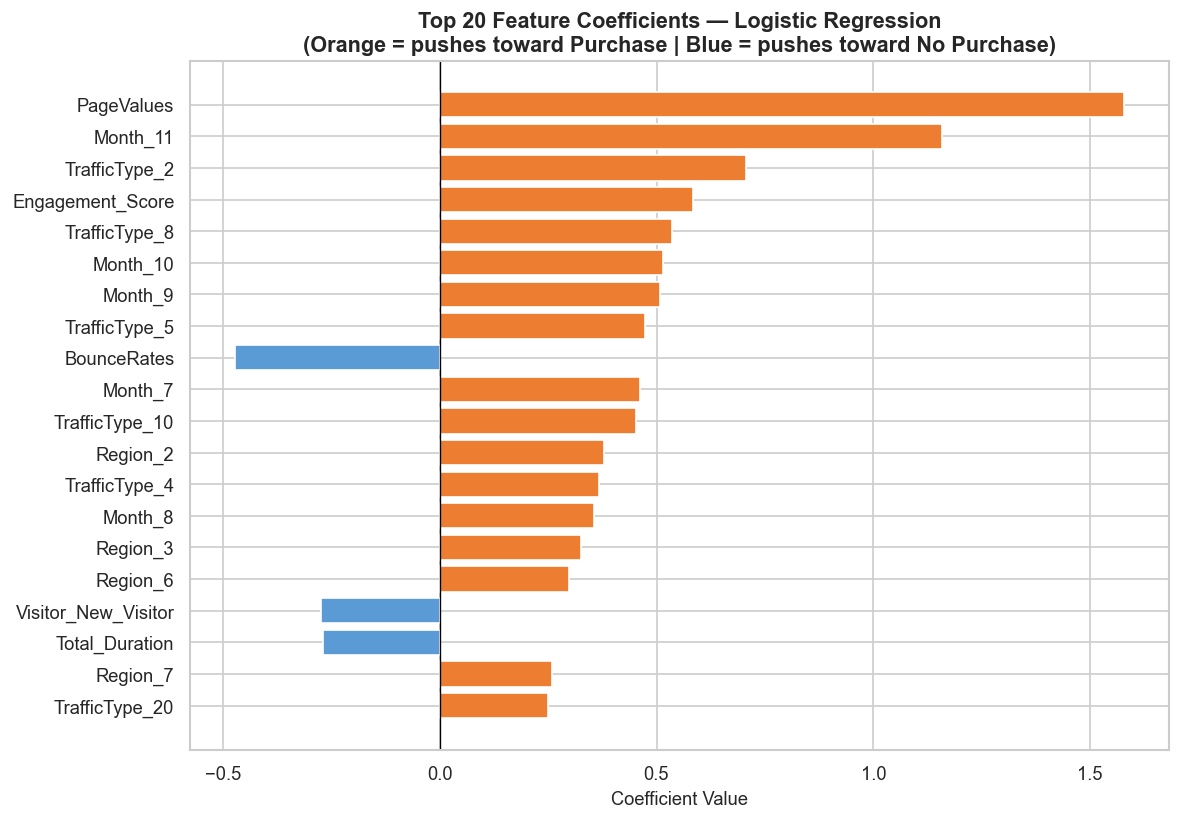

In [49]:
# Feature Importance via Logistic Regression Coefficients
feature_names = X_train_scaled.columns.tolist()
coef_df = pd.DataFrame({
    'Feature'     : feature_names,
    'Coefficient' : lr_best[-1].coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 7))
colors = ['#ed7d31' if c > 0 else '#5b9bd5' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 20 Feature Coefficients — Logistic Regression\n(Orange = pushes toward Purchase | Blue = pushes toward No Purchase)',
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model 2: Random Forest Classifier

Random Forest is an ensemble of decision trees that vote by majority.  
It naturally handles feature interactions and non-linear relationships.

The same **ImbPipeline + SMOTE inside CV** approach is used here for consistency  
and correctness — each fold's training split is independently oversampled.

Key hyperparameters tuned via **GridSearchCV**:
- **n_estimators** — number of trees  
- **max_depth** — maximum tree depth (controls overfitting)  
- **min_samples_leaf** — minimum samples at leaf nodes  
- **max_features** — features considered at each split  

In [50]:
# FIX: SMOTE inside CV pipeline for Random Forest 
# Same approach as Logistic Regression: ImbPipeline ensures SMOTE is applied
# independently on each CV fold — no cross-fold contamination.

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

cv_roc_rf = cross_val_score(rf_pipeline, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1_rf  = cross_val_score(rf_pipeline, X_train_scaled, y_train, cv=cv, scoring='f1',      n_jobs=-1)

print('=== Random Forest — 5-Fold Cross-Validation (SMOTE in pipeline) ===')
print(f'ROC-AUC : {cv_roc_rf.mean():.4f}  ± {cv_roc_rf.std():.4f}')
print(f'F1-Score: {cv_f1_rf.mean():.4f}  ± {cv_f1_rf.std():.4f}')

param_grid_rf = {
    'clf__n_estimators'    : [100, 200, 300],
    'clf__max_depth'       : [None, 10, 20],
    'clf__min_samples_leaf': [1, 2, 5],
    'clf__max_features'    : ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_scaled, y_train)   # fit on unbalanced train; SMOTE happens inside

print(f'\nBest parameters: {grid_rf.best_params_}')
print(f'Best CV ROC-AUC: {grid_rf.best_score_:.4f}')

rf_best = grid_rf.best_estimator_

#  Single prediction block 
y_pred_rf = rf_best.predict(X_test_scaled)
y_prob_rf  = rf_best.predict_proba(X_test_scaled)[:, 1]

print('\n=== Random Forest (Tuned) — Test Set Performance ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Avg Prec : {average_precision_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Purchase', 'Purchase']))


=== Random Forest — 5-Fold Cross-Validation (SMOTE in pipeline) ===
ROC-AUC : 0.9242  ± 0.0049
F1-Score: 0.6799  ± 0.0161
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Best CV ROC-AUC: 0.9265

=== Random Forest (Tuned) — Test Set Performance ===
Accuracy : 0.8890
F1-Score : 0.6845
ROC-AUC  : 0.9247
Avg Prec : 0.7061

              precision    recall  f1-score   support

 No Purchase       0.96      0.91      0.93      2059
    Purchase       0.62      0.77      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.84      0.81      2441
weighted avg       0.90      0.89      0.89      2441



## Random Forest: Visualizations

In [51]:
# Pipeline integrity check
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled  shape:', X_test_scaled.shape)
print('X_train_sm     shape:', X_train_sm.shape)
print('Feature counts match (train_sm vs test):', X_train_sm.shape[1] == X_test_scaled.shape[1])


X_train_scaled shape: (9764, 73)
X_test_scaled  shape: (2441, 73)
X_train_sm     shape: (16476, 73)
Feature counts match (train_sm vs test): True


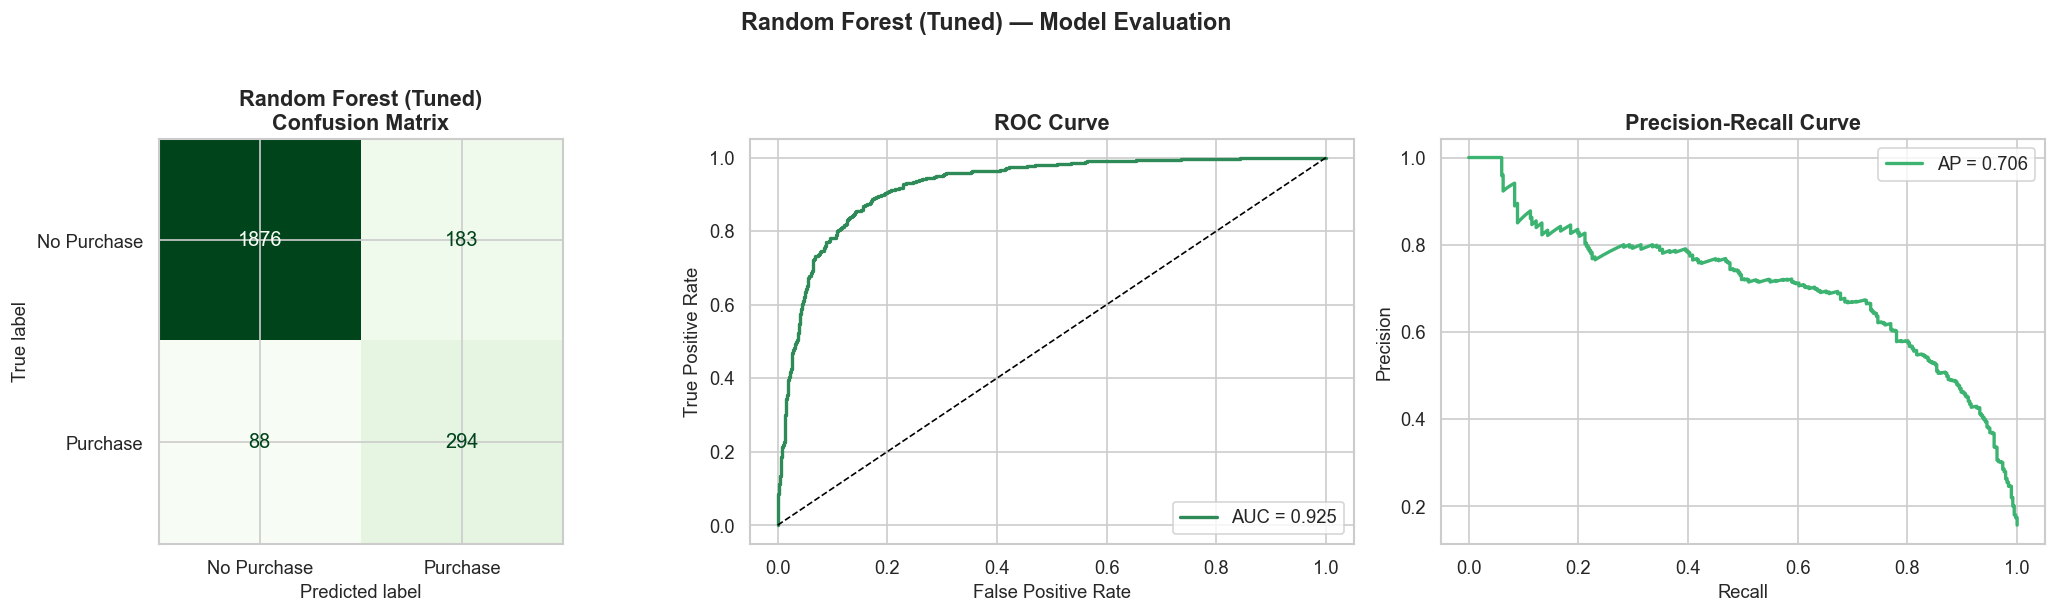

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['No Purchase', 'Purchase']
).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Random Forest (Tuned)\nConfusion Matrix', fontweight='bold')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='seagreen', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_prob_rf):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

# Precision-Recall Curve
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
axes[2].plot(rec_rf, prec_rf, color='mediumseagreen', lw=2,
             label=f'AP = {average_precision_score(y_test, y_prob_rf):.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='upper right')

plt.suptitle('Random Forest (Tuned) — Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


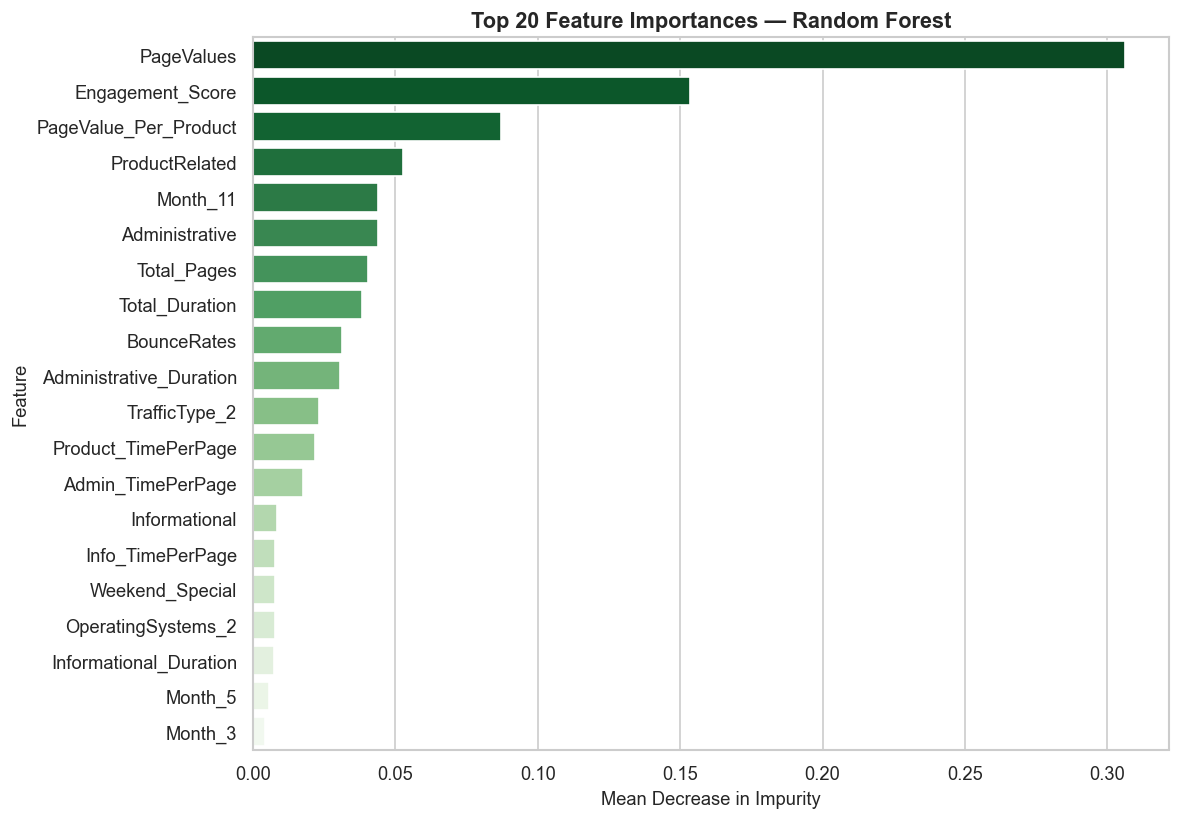

In [53]:
# Feature Importance: Random Forest (Mean Decrease in Impurity)
feat_imp_df = pd.DataFrame({
    'Feature'   : X_train_scaled.columns,
    'Importance': rf_best[-1].feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Greens_r')
plt.title('Top 20 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


## Model Comparison

In [54]:
# Final model comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision (Purchase)', 'Recall (Purchase)'],
    'Logistic Regression': [
        round(accuracy_score(y_test, y_pred_lr),   3),
        round(roc_auc_score(y_test, y_prob_lr),    3),
        round(f1_score(y_test, y_pred_lr),         3),
        round(precision_score(y_test, y_pred_lr),  3),
        round(recall_score(y_test, y_pred_lr),     3),
    ],
    'Random Forest (Tuned)': [
        round(accuracy_score(y_test, y_pred_rf),   3),
        round(roc_auc_score(y_test, y_prob_rf),    3),
        round(f1_score(y_test, y_pred_rf),         3),
        round(precision_score(y_test, y_pred_rf),  3),
        round(recall_score(y_test, y_pred_rf),     3),
    ]
})

print('=' * 60)
print('        FINAL MODEL COMPARISON SUMMARY')
print('=' * 60)
print(comparison.to_string(index=False))
print('=' * 60)


        FINAL MODEL COMPARISON SUMMARY
              Metric  Logistic Regression  Random Forest (Tuned)
            Accuracy                0.860                  0.889
             ROC-AUC                0.899                  0.925
            F1-Score                0.625                  0.685
Precision (Purchase)                0.538                  0.616
   Recall (Purchase)                0.746                  0.770


LR scores : {'Accuracy': 0.86, 'ROC-AUC': 0.899, 'F1-Score': 0.625, 'AP Score': 0.649}
RF scores : {'Accuracy': 0.889, 'ROC-AUC': 0.925, 'F1-Score': 0.685, 'AP Score': 0.706}


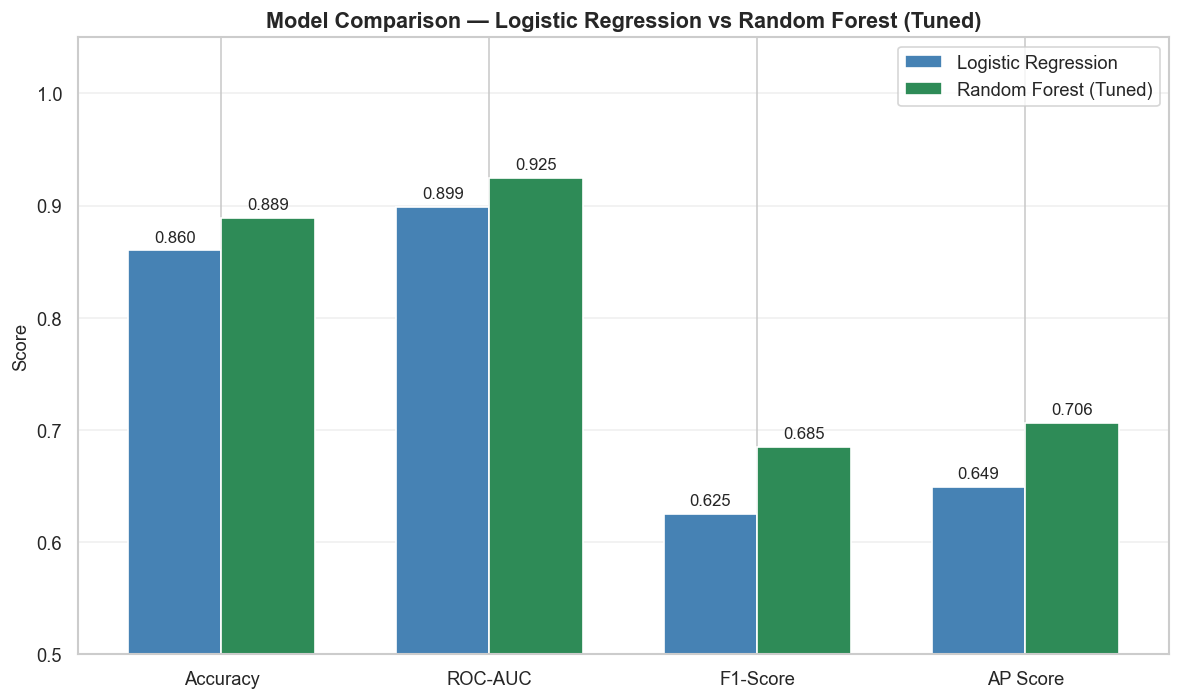

In [55]:
# Visual comparison bar chart
metrics   = ['Accuracy', 'ROC-AUC', 'F1-Score', 'AP Score']
lr_scores = [
    round(accuracy_score(y_test, y_pred_lr),          3),
    round(roc_auc_score(y_test, y_prob_lr),           3),
    round(f1_score(y_test, y_pred_lr),                3),
    round(average_precision_score(y_test, y_prob_lr), 3),
]
rf_scores = [
    round(accuracy_score(y_test, y_pred_rf),          3),
    round(roc_auc_score(y_test, y_prob_rf),           3),
    round(f1_score(y_test, y_pred_rf),                3),
    round(average_precision_score(y_test, y_prob_rf), 3),
]

print(f'LR scores : {dict(zip(metrics, lr_scores))}')
print(f'RF scores : {dict(zip(metrics, rf_scores))}')

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',    color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest (Tuned)',  color='seagreen',   edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Logistic Regression vs Random Forest (Tuned)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. XGBoost Classifier
We now add XGBoost to the comparison. XGBoost is a powerful gradient boosting framework that often outperforms Random Forest on tabular data.

In [56]:
from xgboost import XGBClassifier

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'))
])

param_grid_xgb = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train_scaled, y_train)

print(f'Best parameters: {grid_xgb.best_params_}')
xgb_best = grid_xgb.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_scaled)
y_prob_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

print('\n=== XGBoost (Tuned) — Test Set Performance ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_xgb):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['No Purchase', 'Purchase']))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 300, 'clf__subsample': 0.8}

=== XGBoost (Tuned) — Test Set Performance ===
Accuracy : 0.8812
F1-Score : 0.6763
ROC-AUC  : 0.9317

              precision    recall  f1-score   support

 No Purchase       0.96      0.90      0.93      2059
    Purchase       0.59      0.79      0.68       382

    accuracy                           0.88      2441
   macro avg       0.77      0.85      0.80      2441
weighted avg       0.90      0.88      0.89      2441



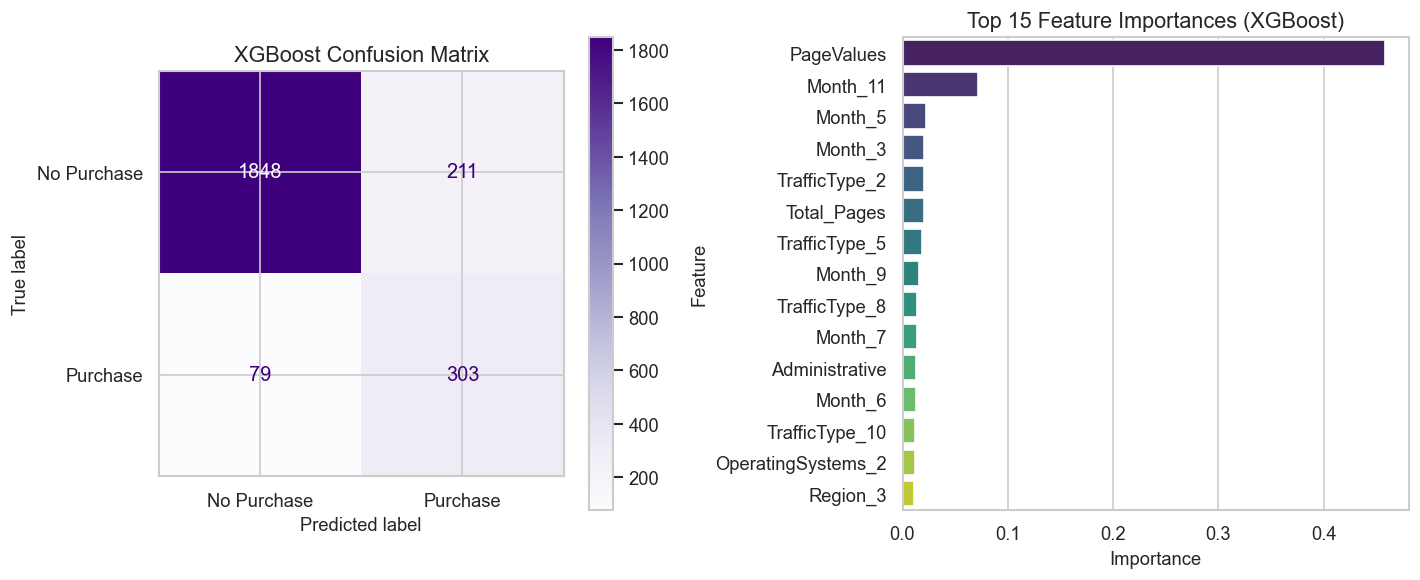

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(xgb_best, X_test_scaled, y_test, 
                                     display_labels=['No Purchase', 'Purchase'], 
                                     cmap='Purples', ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix')

feat_imp_xgb = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': xgb_best.named_steps['clf'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

sns.barplot(data=feat_imp_xgb, x='Importance', y='Feature', palette='viridis', ax=axes[1])
axes[1].set_title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

In [58]:
comparison_final = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr), roc_auc_score(y_test, y_prob_lr), 
        f1_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf), 
        f1_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf)
    ],
    'XGBoost': [
        accuracy_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_prob_xgb), 
        f1_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_xgb)
    ]
})
display(comparison_final.round(3))

,Metric,Logistic Regression,Random Forest,XGBoost
0,Accuracy,0.860,0.889,0.881
1,ROC-AUC,0.899,0.925,0.932
2,F1-Score,0.625,0.685,0.676
3,Precision,0.538,0.616,0.589
4,Recall,0.746,0.770,0.793
